In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [64]:
df = pd.read_csv('insurance.csv')

In [65]:
df

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1333,1333,50,male,30.970,3,no,northwest,10600.54830
1334,1334,18,female,31.920,0,no,northeast,2205.98080
1335,1335,18,female,36.850,0,no,southeast,1629.83350
1336,1336,21,female,25.800,0,no,southwest,2007.94500


#EDA

In [66]:
df.shape

(1338, 8)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [68]:
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [69]:
df.tail()

,index,age,sex,bmi,children,smoker,region,charges
1333,1333,50,male,30.97,3,no,northwest,10600.5483
1334,1334,18,female,31.92,0,no,northeast,2205.9808
1335,1335,18,female,36.85,0,no,southeast,1629.8335
1336,1336,21,female,25.80,0,no,southwest,2007.9450
1337,1337,61,female,29.07,0,yes,northwest,29141.3603


In [70]:
df.describe()

,index,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,668.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.250000,27.000000,26.296250,0.000000,4740.287150
50%,668.500000,39.000000,30.400000,1.000000,9382.033000
75%,1002.750000,51.000000,34.693750,2.000000,16639.912515
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


In [71]:
df.isnull().sum()

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [72]:
df.columns

Index(['index', 'age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'charges'],
      dtype='object')

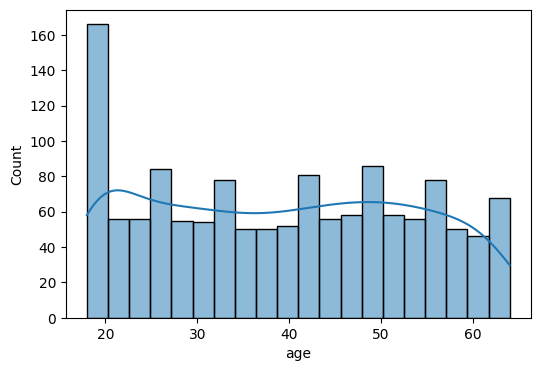

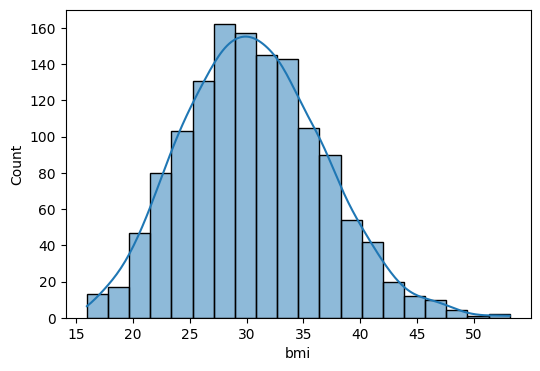

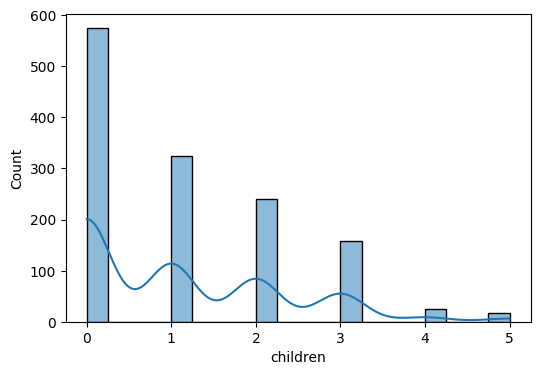

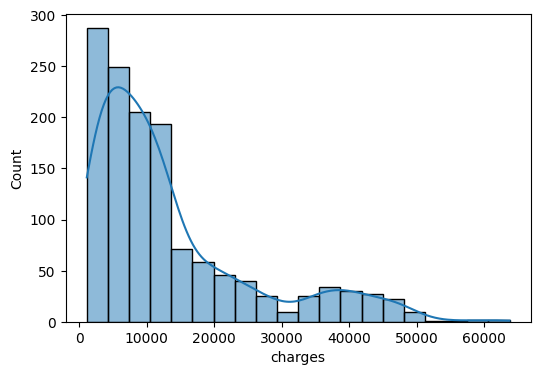

In [73]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde= True,bins = 20)

<Axes: xlabel='children', ylabel='count'>

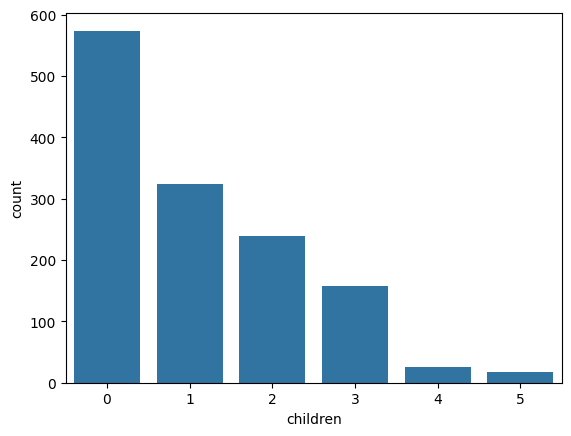

In [74]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

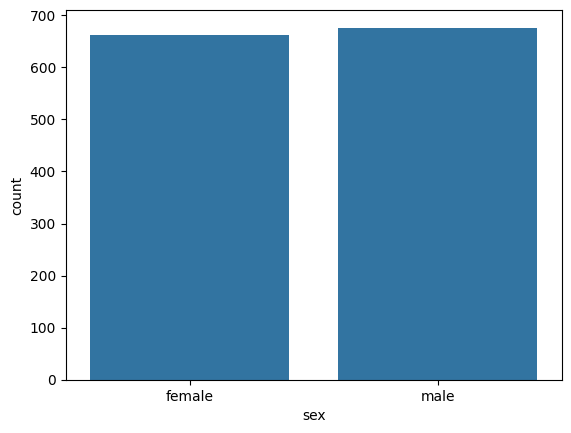

In [75]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

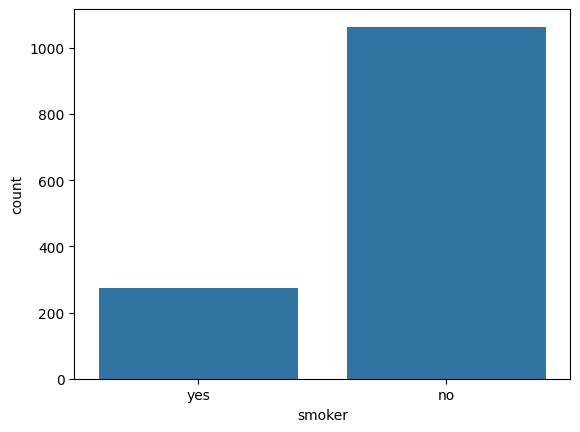

In [76]:
sns.countplot(x = df['smoker'])

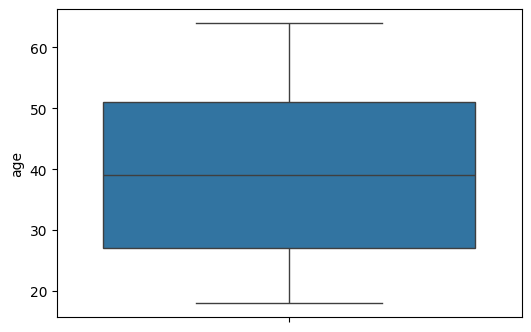

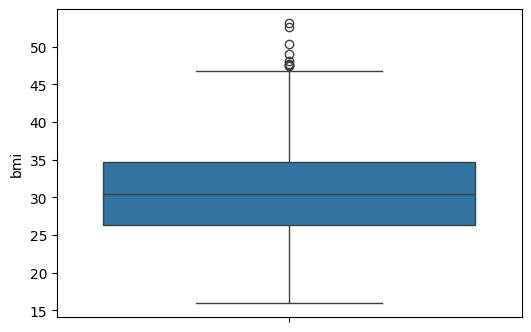

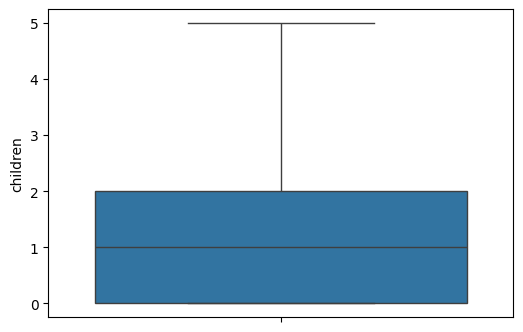

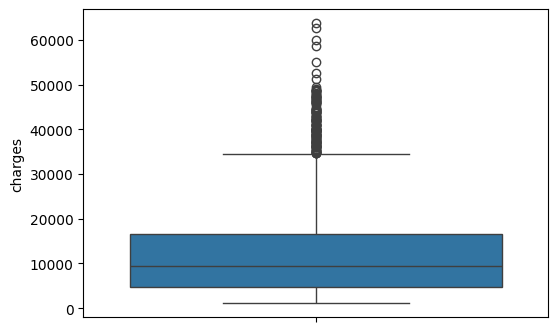

In [77]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])

<Axes: >

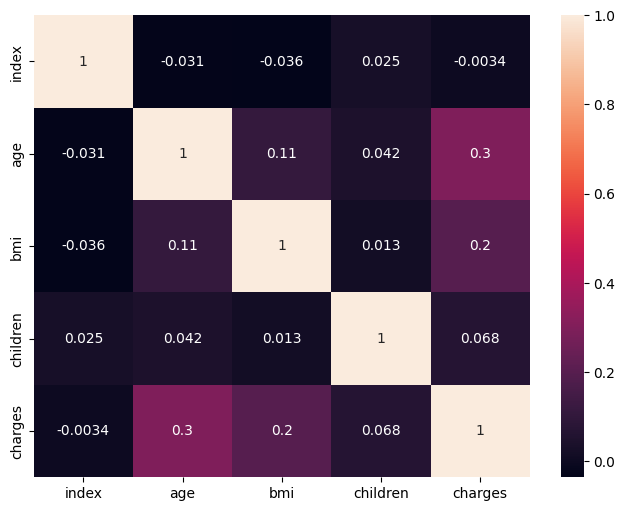

In [78]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True),annot=True)

#Data Cleaning and Preprocessing

In [79]:
df_cleaned = df.copy()
df_cleaned.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
df_cleaned.drop_duplicates(inplace=True)

In [81]:
df_cleaned.isnull().sum()

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [82]:
df_cleaned.dtypes

index         int64
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [83]:
df_cleaned['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [84]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [85]:
df_cleaned.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,1,27.900,0,yes,southwest,16884.92400
1,1,18,0,33.770,1,no,southeast,1725.55230
2,2,28,0,33.000,3,no,southeast,4449.46200
3,3,33,0,22.705,0,no,northwest,21984.47061
4,4,32,0,28.880,0,no,northwest,3866.85520


In [86]:
df_cleaned['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [87]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0,'yes':1})

In [88]:
df_cleaned.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,1,27.900,0,1,southwest,16884.92400
1,1,18,0,33.770,1,0,southeast,1725.55230
2,2,28,0,33.000,3,0,southeast,4449.46200
3,3,33,0,22.705,0,0,northwest,21984.47061
4,4,32,0,28.880,0,0,northwest,3866.85520


In [89]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace= True)

In [90]:
df_cleaned.head()

,index,age,is_female,bmi,children,is_smoker,region,charges
0,0,19,1,27.900,0,1,southwest,16884.92400
1,1,18,0,33.770,1,0,southeast,1725.55230
2,2,28,0,33.000,3,0,southeast,4449.46200
3,3,33,0,22.705,0,0,northwest,21984.47061
4,4,32,0,28.880,0,0,northwest,3866.85520


In [91]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [92]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)

In [93]:
df_cleaned.head()

,index,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,0,19,1,27.900,0,1,16884.92400,False,False,True
1,1,18,0,33.770,1,0,1725.55230,False,True,False
2,2,28,0,33.000,3,0,4449.46200,False,True,False
3,3,33,0,22.705,0,0,21984.47061,True,False,False
4,4,32,0,28.880,0,0,3866.85520,True,False,False


In [94]:
df_cleaned = df_cleaned.astype(int)

In [95]:
df_cleaned

,index,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,0,19,1,27,0,1,16884,0,0,1
1,1,18,0,33,1,0,1725,0,1,0
2,2,28,0,33,3,0,4449,0,1,0
3,3,33,0,22,0,0,21984,1,0,0
4,4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,1333,50,0,30,3,0,10600,1,0,0
1334,1334,18,1,31,0,0,2205,0,0,0
1335,1335,18,1,36,0,0,1629,0,1,0
1336,1336,21,1,25,0,0,2007,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

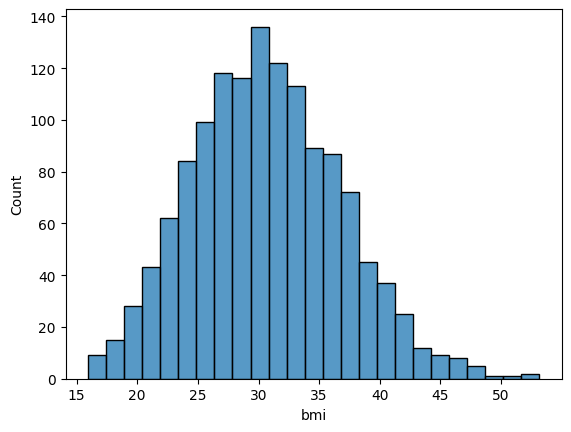

In [96]:
#feature engineering and extraction
sns.histplot(df['bmi'])

In [97]:
df_cleaned['bmi_category']= pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels = ['Underweight','Normal','overweight','obese']

)
                                   

In [98]:
df_cleaned

,index,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,0,19,1,27,0,1,16884,0,0,1,overweight
1,1,18,0,33,1,0,1725,0,1,0,obese
2,2,28,0,33,3,0,4449,0,1,0,obese
3,3,33,0,22,0,0,21984,1,0,0,Normal
4,4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,1333,50,0,30,3,0,10600,1,0,0,obese
1334,1334,18,1,31,0,0,2205,0,0,0,obese
1335,1335,18,1,36,0,0,1629,0,1,0,obese
1336,1336,21,1,25,0,0,2007,0,0,1,overweight


In [99]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

In [100]:
df_cleaned = df_cleaned.astype(int)

In [101]:
df_cleaned.head()

,index,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,0,19,1,27,0,1,16884,0,0,1,0,1,0
1,1,18,0,33,1,0,1725,0,1,0,0,0,1
2,2,28,0,33,3,0,4449,0,1,0,0,0,1
3,3,33,0,22,0,0,21984,1,0,0,1,0,0
4,4,32,0,28,0,0,3866,1,0,0,0,1,0


In [102]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [103]:
df_cleaned.head()

,index,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,0,1,0
1,1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,0,0,1
2,2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,0,0,1
3,3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,1,0,0
4,4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,0,1,0


In [104]:
from scipy.stats import pearsonr, chi2_contingency

# --- Feature lists ---
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_overweight', 'bmi_category_obese'
]

# --- Pearson correlation vs target ('charges') ---
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)


In [105]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_overweight', 'bmi_category_obese'
]

In [106]:
alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

In [107]:
# --- Optional: select final dataframe columns (example) ---
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
                       'region_southeast', 'bmi_category_obese', 'region_southwest',
                       'bmi_category_overweight', 'bmi_category_Normal', 'region_northwest']]


In [108]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese,region_southwest,bmi_category_overweight,bmi_category_Normal,region_northwest
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,1,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1,0,0,0,0
2,-0.797954,0,0.462657,1.580926,0,4449,1,1,0,0,0,0
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0,0,0,1,1
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1,0,0,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1,0,0,0,0
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1,0,0,0,0
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0,1,1,0,0


In [109]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
                       'region_southeast', 'bmi_category_obese',]]

In [110]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1
2,-0.797954,0,0.462657,1.580926,0,4449,1,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0


In [111]:
from sklearn.model_selection import train_test_split

In [112]:
x= final_df.drop('charges',axis=1)
y= final_df['charges']

In [113]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state=42)

In [115]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
y_pred = model.predict(x_test)

In [119]:
from sklearn.metrics import r2_score

In [120]:
r2 = r2_score(y_test,y_pred)
r2
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7526983088688454